# Array Efficiency Analysis for 2024 / 2025

**Author:** Marwan Negm

**Date:** 2026-1-06

**Relevant Links:**
- [Monday Post](https://ubcsolar26.monday.com/boards/9565353662/pulses/9773052619)
- [DR0](https://docs.google.com/document/d/19uLX7iUFfbZED2y24udkK1MQrO5hOUxp5Yb9y1QJywU/edit?usp=sharing)
- The following code is mostly taken from 2024 efficiency analysis, but streamlined and generalised to have fewer plots



## Imports

In [1]:
import scripts.string_power_functions as sf
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import pytz
import matplotlib.pyplot as plt
import numpy as np
import pvlib
from scipy.signal import butter, filtfilt

## Data Acquisition

In [2]:
## Parameters: ##
# Location Information
latitude = 37.002923
longitude = -86.3686424

# Surface Area
total_surface_area = 4

# Dates: Somewhat important that you format it "year-month-day"
# 2024:
# start_date_str = "2024-07-16"
# end_date_str = "2024-07-18"

# 2025:
start_date_str = "2025-07-01"
end_date_str = "2025-07-03"

start_date = list(map(int, start_date_str.split("-"))) # List of integers representing the dates: [year, month, day]
end_date = list(map(int, end_date_str.split("-")))

# Times
year = start_date[0]

month = start_date[1]

day1 = start_date[2]
day2 = start_date[2] + 1
day3 = start_date[2] + 2

# Finding location for pvLib
location = pvlib.location.Location(latitude, longitude, tz='America/Chicago', altitude=None, name=None)

# Find the start and end times and localise it to UTC
start_time: datetime = pytz.timezone('UTC').localize(datetime(year, month, start_date[2], 12))
end_time: datetime   = pytz.timezone('UTC').localize(datetime(year, month, end_date[2] + 1, 6))

print(f"Start time is {start_time}; End time is {end_time}")

# For 2025 : ["A", "B", "C"], "InputCurrent", "InputVoltage"
# For 2024 : ["1", "2"], "CurrentSensor", "VoltSensor"

total_power_series = sf.get_total_power(start_time, end_time, ["A", "B", "C"], "InputCurrent", "InputVoltage")

Start time is 2025-07-01 12:00:00+00:00; End time is 2025-07-04 06:00:00+00:00
InputCurrentA
InputVoltageA
InputCurrentB
InputVoltageB
InputCurrentC
InputVoltageC


## Analysis

### This block shifts the data by 7 hours because InlfuxDB is in the wrong timezone:

In [3]:
shifted_power_series = total_power_series.copy()

shifted_power_series._start = total_power_series._start + timedelta(hours=(7)) #Time has to be shifted by 7 hours because Influx takes in UTC 
shifted_power_series._stop = total_power_series._stop + timedelta(hours=(7))

### Generate the new irradiance series the existing time series:

In [4]:
date_time_x_axis = shifted_power_series.datetime_x_axis

new_irradiance_series = location.get_clearsky(date_time_x_axis)

### Preform a low pass filter to reduce noise on the data:
This is where my understanding fails slightly, parameters were selected arbitrarily until enough noise was cut off.

In [5]:
N = len(shifted_power_series)  # Number of data points
sampling_rate = 1/shifted_power_series._period  # Sampling rate (in Hz)

# Perform FFT
fft_result = np.fft.fft(shifted_power_series)
# Frequency axis (for single-sided spectrum)
frequencies = np.fft.fftfreq(N, d=shifted_power_series._period)  # Positive frequencies only
fft_magnitude = np.abs(fft_result)  # Magnitude of the FFT (single-sided)

# Filter parameters #
cutoff_freq = 1  # Cutoff frequency in Hz
fs = 20000  # Sampling rate in Hz
order = 4  # Filter order

# Design the low-pass filter
nyq = 0.5 * fs
normal_cutoff = cutoff_freq / nyq
b, a = butter(order, normal_cutoff, btype='lowpass')

filtered_power_series = filtfilt(b, a, shifted_power_series)

# (OPTIONAL) Plot the FFT
# plt.plot(frequencies, fft_magnitude)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Magnitude')
# plt.title('FFT of Signal')
# plt.yscale('log')
# plt.grid(True)
# plt.show()

### Graph the power series
This is done to see how the data looks before and after the main processing step (low pass filter)

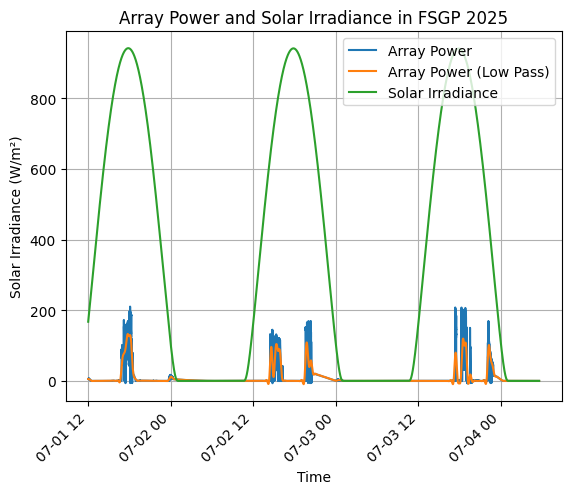

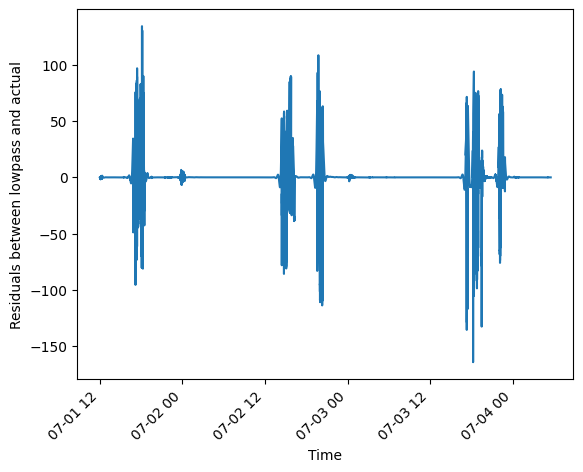

In [6]:
# Graph of the power series
plt.plot(date_time_x_axis, shifted_power_series/total_surface_area, label = 'Array Power') # The arrays were 4 m², this calculates power/m²
plt.plot(date_time_x_axis, filtered_power_series/total_surface_area, label = 'Array Power (Low Pass)')
plt.plot(date_time_x_axis, new_irradiance_series['ghi'], label = 'Solar Irradiance')

plt.xticks(rotation = 45, ha='right')
plt.title(f"Array Power and Solar Irradiance in FSGP {year}")

plt.grid()

plt.legend(loc = 'upper right')

plt.ylabel("Solar Irradiance (W/m²)")
plt.xlabel("Time")

plt.show()

# Graph of residuals
plt.plot(date_time_x_axis, (filtered_power_series - shifted_power_series)/total_surface_area)
plt.xticks(rotation = 45, ha='right')
plt.ylabel("Residuals between lowpass and actual")
plt.xlabel("Time")
plt.show()



### Mask the Data and Extract Peak Efficiency
Using numpy, the data was masked based on day and only when the irradiance was greater than 750 watts. This was done to make sure to only include times when there solar cells are getting enough power to be accurately measured. All code which excludes day 2 is commented out.

In [7]:
mask = new_irradiance_series['ghi'] > 750 # Only show data where the irradiance is greater than 750 watts

# Day masks, maintains the previous irradiance mask
mask_day1 = np.logical_and(np.logical_and((mask), date_time_x_axis > datetime(year, month, day1, 18)), date_time_x_axis < datetime(year, month, day1 + 1, 12))
mask_day2 = np.logical_and(np.logical_and((mask), date_time_x_axis > datetime(year, month, day2, 18)), date_time_x_axis < datetime(year, month, day2 + 1, 12))
mask_day3 = np.logical_and(np.logical_and((mask), date_time_x_axis > datetime(year, month, day3, 18)), date_time_x_axis < datetime(year, month, day3 + 1, 12))

mask_without_day_2 = np.logical_or(mask_day1, mask_day3)

#Filter both the x and y data using the mask
x_filtered = date_time_x_axis[mask]
y_filtered = (filtered_power_series[mask] / total_surface_area) / new_irradiance_series['ghi'][mask]

y_filtered_without_day_2 = (filtered_power_series[mask_without_day_2] / total_surface_area) / new_irradiance_series['ghi'][mask_without_day_2]


### Find Peak and Average efficiencies
Finds the average and peak efficiencies, again all code which excludes day 2 is commented out.

Average efficiency is 3.00%
Peak efficiency is 14.10%


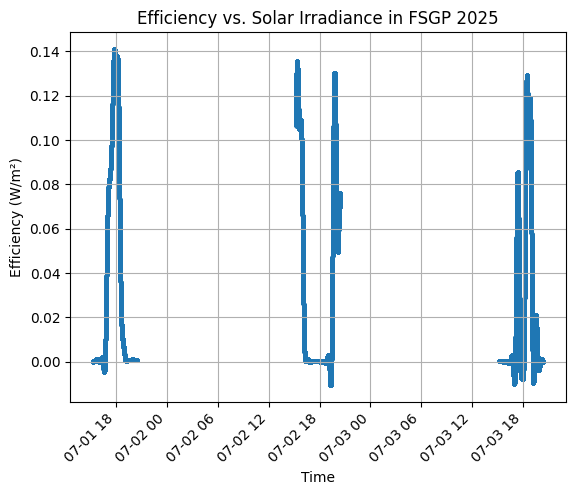

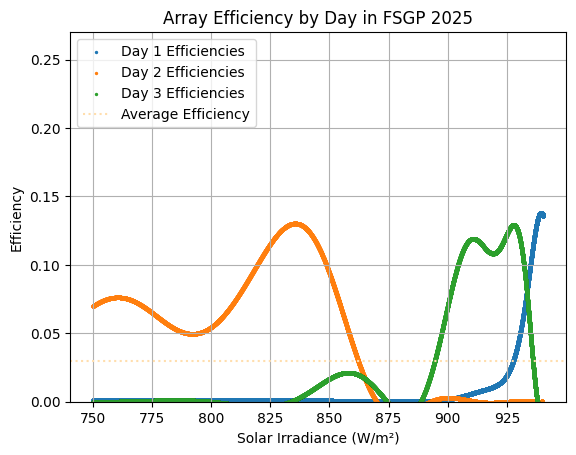

In [8]:
# Find average and peak efficiencies
average_efficiency = np.mean(y_filtered)
peak_efficiency = np.max(y_filtered)

#average_efficiency_without_day_2 =  np.mean(y_filtered_without_day_2)
#print(f"Average efficiency without day 2 is {average_efficiency_without_day_2*100:.2f}%")

print(f"Average efficiency is {average_efficiency*100:.2f}%")
print(f"Peak efficiency is {peak_efficiency*100:.2f}%")

## Plot the filtered data ##
plt.scatter(x_filtered, y_filtered, s=2)
plt.grid()

plt.ylabel("Efficiency (W/m²)")
plt.xlabel("Time")

plt.xticks(rotation = 45, ha='right')

plt.title(f"Efficiency vs. Solar Irradiance in FSGP {year}")

plt.show()

#Plotting efficiency by day. Used in 2024 to show how weird day 2 is
plt.scatter(new_irradiance_series['ghi'][mask_day1], (filtered_power_series[mask_day1] / total_surface_area) / new_irradiance_series['ghi'][mask_day1], s=2, label = 'Day 1 Efficiencies')
plt.scatter(new_irradiance_series['ghi'][mask_day2], (filtered_power_series[mask_day2] / total_surface_area) / new_irradiance_series['ghi'][mask_day2], s=2, label = 'Day 2 Efficiencies')
plt.scatter(new_irradiance_series['ghi'][mask_day3], (filtered_power_series[mask_day3] / total_surface_area) / new_irradiance_series['ghi'][mask_day3], s=2, label = 'Day 3 Efficiencies')

plt.axhline(average_efficiency, label='Average Efficiency', ls = ':', color = 'navajowhite')
#plt.axhline(average_efficiency_without_day_2, label='Average Efficiency (Day 2 excluded)', ls = ':', color = 'lightseagreen')

plt.legend(loc = 'upper left')
plt.grid()
plt.ylim(0, 0.27)

plt.ylabel("Efficiency")
plt.xlabel("Solar Irradiance (W/m²)")

plt.title(f"Array Efficiency by Day in FSGP {year}")

plt.show()


#### Plot to show the change in data from the Lowpass filter

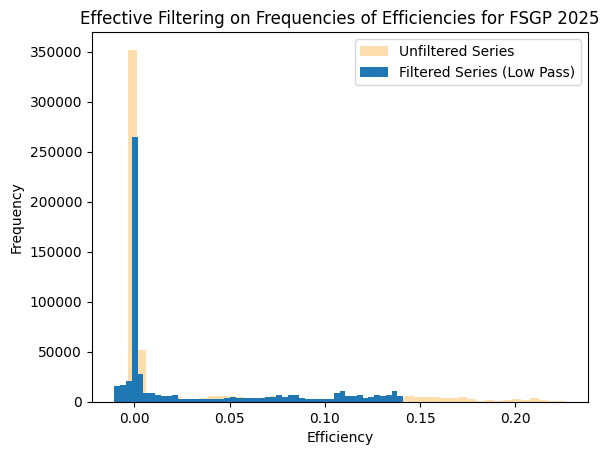

In [9]:
plt.hist((shifted_power_series[mask]/total_surface_area)/new_irradiance_series['ghi'][mask], bins = 50, label='Unfiltered Series', color='navajowhite')
plt.hist((filtered_power_series[mask] / total_surface_area) / new_irradiance_series['ghi'][mask], bins=50, label='Filtered Series (Low Pass)')

plt.legend()

plt.ylabel("Frequency")
plt.xlabel("Efficiency")

plt.title(f"Effective Filtering on Frequencies of Efficiencies for FSGP {year}")

plt.show()

#### Plots by day

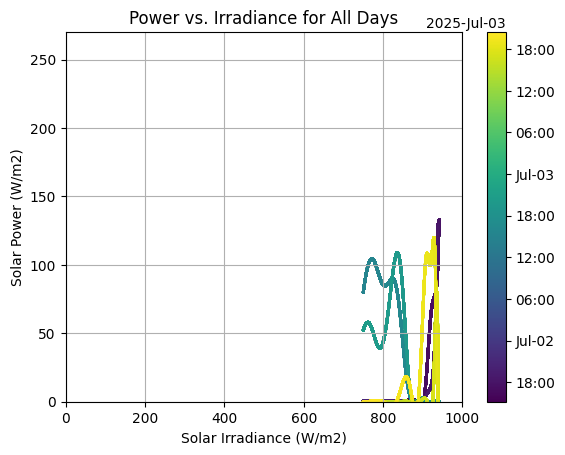

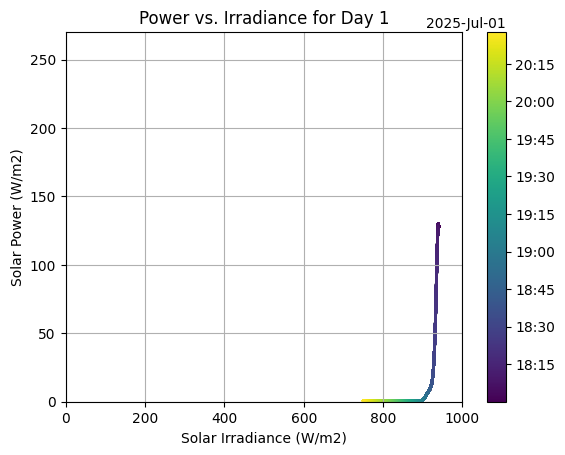

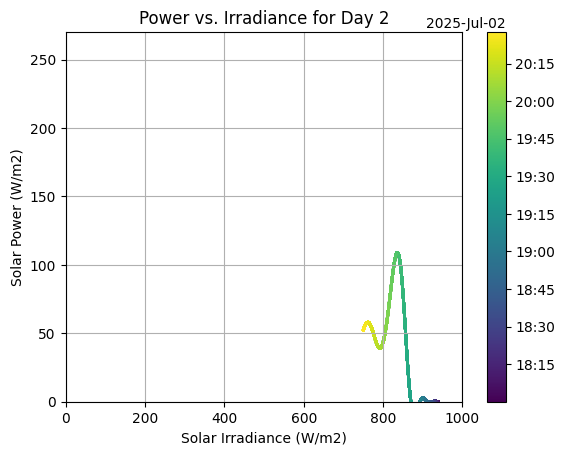

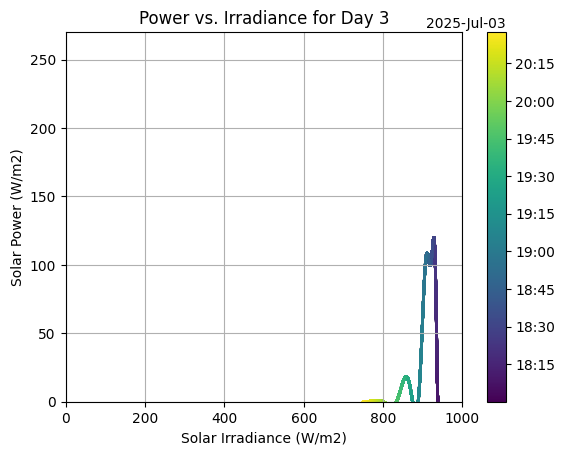

In [10]:
def showDayPlot(mask, label: str):
    # Capture the mappable object returned by plt.scatter
    scatter = plt.scatter(new_irradiance_series['ghi'][mask], (filtered_power_series[mask] / total_surface_area), s=1, c=mdates.date2num(date_time_x_axis[mask]))
    plt.title(f'Power vs. Irradiance for {label}')
    #plt.scatter(new_irradiance_series['ghi'][mask], new_irradiance_series['ghi'][mask]*average_efficiency_without_day_2, s=2, label='Average Efficiency (Excluding Day 2)')

    # Create the color bar and store the object
    cbar = plt.colorbar()

    # Apply date formatting to the color bar's y-axis #
    # Get the AutoDateLocator to find appropriate tick locations
    locator = mdates.AutoDateLocator()
    cbar.ax.yaxis.set_major_locator(locator)
    
    # Apply a DateFormatter
    cbar.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    plt.xlim(0,1000)
    plt.ylim(0,270)

    plt.grid()

    plt.ylabel("Solar Power (W/m2)")
    plt.xlabel("Solar Irradiance (W/m2)")

    plt.show()

showDayPlot(mask, 'All Days')
showDayPlot(mask_day1, 'Day 1')
showDayPlot(mask_day2, 'Day 2')
showDayPlot(mask_day3, 'Day 3')
